In [1]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import argparse
import json
from typing import Dict, Optional, Tuple
import sys
import time
from datetime import datetime
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc, mean_squared_error
from splicevo.data.data_loader import load_memmap_data


/home/elek/miniforge3/envs/splicevo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup paths

In [3]:
test_data = "/home/elek/sds/sd17d003/Anamaria/splicevo/data/splits_small_5kb/mouse_rat_human/test"
pred_dir = "/home/elek/sds/sd17d003/Anamaria/splicevo/predictions/transformer/small_mouse_rat_human_5kb"
output_dir = "/home/elek/sds/sd17d003/Anamaria/splicevo/predictions/transformer/small_mouse_rat_human_5kb/evaluation"

test_data_dir = Path(test_data)
pred_dir = Path(pred_dir)
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
def load_sparse_predictions(pred_dir: Path, test_data_dir: Path, log_fn=print) -> Tuple:
    """
    Load predictions and ground truth from sparse parquet format.
    
    Args:
        pred_dir: Directory containing prediction parquet files
        test_data_dir: Directory containing test data
        log_fn: Logging function
    
    Returns:
        Tuple of (pred_labels, pred_probs, pred_usage, metadata, true_labels, true_usage)
        All as dense numpy arrays for compatibility with evaluation functions
    """
    log_fn("Loading sparse predictions...")
    
    # Load metadata
    meta_file = pred_dir / 'predictions_metadata.json'
    with open(meta_file, 'r') as f:
        pred_meta = json.load(f)
    
    # Load test data metadata to get dimensions
    test_meta_file = test_data_dir / 'metadata.json'
    with open(test_meta_file, 'r') as f:
        test_meta = json.load(f)
    
    # Get dimensions from test data
    sequences, labels_true_sparse, usage_true_sparse, metadata = load_memmap_data(
        test_data_dir,
        load_labels=True,
        load_usage=True
    )
    
    n_samples = sequences.shape[0]
    seq_len = sequences.shape[1]
    context_len = test_meta.get('context_len', 450)
    central_len = seq_len - 2 * context_len
    
    # Determine number of conditions from usage data
    if usage_true_sparse is not None and len(usage_true_sparse) > 0:
        if 'condition_idx' in usage_true_sparse.columns:
            n_conditions = usage_true_sparse['condition_idx'].max() + 1
        else:
            # Try to infer from test metadata
            n_conditions = len(test_meta.get('condition_names', []))
            if n_conditions == 0:
                # Default fallback
                n_conditions = 8
                log_fn(f"  Warning: Could not determine n_conditions from data, using default: {n_conditions}")
    else:
        # Try to infer from test metadata
        n_conditions = len(test_meta.get('condition_names', []))
        if n_conditions == 0:
            n_conditions = 0
            log_fn(f"  Warning: No usage data found, n_conditions set to 0")
    
    log_fn(f"  Dimensions: {n_samples} samples, central length: {central_len}, conditions: {n_conditions}")
    
    # Initialize dense arrays
    pred_labels = np.zeros((n_samples, central_len), dtype=np.int8)
    pred_probs = np.zeros((n_samples, central_len, 3), dtype=np.float32)  # 3 classes
    
    if n_conditions > 0:
        pred_usage = np.zeros((n_samples, central_len, n_conditions), dtype=np.float32)
        true_usage = np.full((n_samples, central_len, n_conditions), np.nan, dtype=np.float32)
    else:
        pred_usage = np.zeros((n_samples, central_len, 0), dtype=np.float32)
        true_usage = np.full((n_samples, central_len, 0), np.nan, dtype=np.float32)
    
    # Load predicted labels
    labels_pred_file = pred_dir / 'labels_pred.parquet'
    if labels_pred_file.exists():
        labels_pred_df = pd.read_parquet(labels_pred_file)
        pred_labels = labels_pred_df
    
    # Load predicted probabilities
    probs_pred_file = pred_dir / 'probs_pred.parquet'
    if probs_pred_file.exists():
        probs_pred_df = pd.read_parquet(probs_pred_file)
        log_fn(f"  Loaded {len(probs_pred_df)} predicted probability entries")
        pred_probs = probs_pred_df
    
    # Load predicted usage
    usage_pred_file = pred_dir / 'usage_pred.parquet'
    if usage_pred_file.exists() and n_conditions > 0:
        usage_pred_df = pd.read_parquet(usage_pred_file)
        log_fn(f"  Loaded {len(usage_pred_df)} predicted usage entries")
        pred_usage = usage_pred_df
    
    return pred_labels, pred_probs, pred_usage, test_meta, metadata

def evaluate_splice_site_classification(true_labels, pred_probs, output_dir: Path, log_fn=print) -> Dict:
    """
    Evaluate splice site classification performance.
    
    Args:
        true_labels: DataFrame with columns (sample_idx, position, label) or numpy array
        pred_probs: DataFrame with columns (sample_idx, position, class_id, probability) or numpy array
        output_dir: Output directory for plots
        log_fn: Logging function
    """
    
    results = {}
    
    # Handle DataFrame inputs efficiently
    if isinstance(pred_probs, pd.DataFrame):
        log_fn("Processing sparse probability predictions...")
        
        # Pivot pred_probs to have class_id as columns
        pred_wide = pred_probs.pivot_table(
            index=['sample_idx', 'position'],
            columns='class_id',
            values='probability',
            fill_value=0.0
        )
        pred_wide.columns = [f'prob_class_{int(c)}' for c in pred_wide.columns]
        pred_wide = pred_wide.reset_index()
        
        if isinstance(true_labels, pd.DataFrame):
            
            # Merge true labels with predictions
            merged = pred_wide.merge(
                true_labels[['sample_idx', 'position', 'label']],
                on=['sample_idx', 'position'],
                how='left'
            )
            merged['label'] = merged['label'].fillna(0).astype(int)
        else:
            # true_labels is numpy array - need to convert positions to labels
            log_fn("Converting numpy true labels to match predictions...")
            merged = pred_wide.copy()
            merged['label'] = 0  # default background
            # This would need custom logic to map from array indices
            
        log_fn(f"Evaluating {len(merged)} positions...")
        
        # Build evaluation arrays for each class
        y_true_by_class = {}
        y_scores_by_class = {}
        
        for class_idx in range(3):
            prob_col = f'prob_class_{class_idx}'
            
            if class_idx == 0:
                # Background: positive if NOT this class
                y_true_by_class[class_idx] = (merged['label'] != class_idx).astype(int).values
                y_scores_by_class[class_idx] = (1 - merged[prob_col]).values
            else:
                # Splice sites: positive if IS this class
                y_true_by_class[class_idx] = (merged['label'] == class_idx).astype(int).values
                y_scores_by_class[class_idx] = merged[prob_col].values
    
    else:
        # Handle numpy array inputs (backwards compatibility)
        log_fn("Processing dense array predictions...")
        
        if isinstance(true_labels, np.ndarray):
            y_true_by_class = {}
            y_scores_by_class = {}
            
            for class_idx in range(3):
                if class_idx == 0:
                    y_true_by_class[class_idx] = (true_labels != class_idx).astype(int).reshape(-1)
                    y_scores_by_class[class_idx] = (1 - pred_probs[:, :, class_idx]).reshape(-1)
                else:
                    y_true_by_class[class_idx] = (true_labels == class_idx).astype(int).reshape(-1)
                    y_scores_by_class[class_idx] = pred_probs[:, :, class_idx].reshape(-1)
        else:
            raise ValueError("Unsupported combination of input types")
    
    # Calculate PR-AUC scores
    log_fn("Calculating Precision-Recall AUC scores...")
    pr_auc_scores = {}
    class_labels = {0: 'no splice site', 1: 'donor', 2: 'acceptor'}
    class_colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green'}
    
    plt.figure(figsize=(5, 4))
    for class_idx in range(3):
        color = class_colors[class_idx]
        label = class_labels[class_idx]
        
        y_true = y_true_by_class[class_idx]
        y_scores = y_scores_by_class[class_idx]
        
        if len(y_true) > 0 and np.sum(y_true) > 0:
            precision, recall, _ = precision_recall_curve(y_true, y_scores)
            pr_auc = auc(recall, precision)
            pr_auc_scores[class_idx] = pr_auc
            
            plt.plot(
                recall, precision,
                label=f"{label} (AUC = {pr_auc:.3f})",
                linewidth=2,
                color=color
            )
        else:
            pr_auc_scores[class_idx] = 0.0
            log_fn(f"  Warning: No positive samples for {label}")
    
    plt.xlabel("Recall", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.title("Precision–Recall Curves for Splice Site Classes", fontsize=14)
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    if output_dir is not None:
        pr_auc_plot = output_dir / "splice_site_pr_auc.png"
        plt.savefig(pr_auc_plot, dpi=150)
        plt.close()
        log_fn(f"Saved PR-AUC plot to {pr_auc_plot}")
    else:
        plt.show()

    for c, auc_score in pr_auc_scores.items():
        log_fn(f"  PR-AUC for {class_labels[c]}: {auc_score:.4f}")
    
    results['pr_auc'] = pr_auc_scores
    
    # Top-k accuracy
    log_fn("Calculating top-k accuracy...")
    def top_k_accuracy(y_true, y_scores):
        k = int(np.sum(y_true))
        if k == 0:
            return 0.0
        threshold = np.sort(y_scores)[-k] if k <= len(y_scores) else y_scores.min()
        y_pred = (y_scores >= threshold).astype(int)
        accuracy = np.sum((y_pred == 1) & (y_true == 1)) / k
        return accuracy
    
    top_k_acc = {}
    for class_idx in range(3):
        y_true = y_true_by_class[class_idx]
        y_scores = y_scores_by_class[class_idx]
        
        if len(y_true) > 0:
            acc = top_k_accuracy(y_true, y_scores)
            top_k_acc[class_idx] = acc
            log_fn(f"  Top-k accuracy for {class_labels[class_idx]}: {acc:.4f}")
        else:
            top_k_acc[class_idx] = 0.0
    
    results['top_k_acc'] = top_k_acc
    
    return results

def calculate_condition_correlations(all_data_df: pd.DataFrame, group_by=['tissue'], log_fn=print) -> pd.DataFrame:
    """Calculate correlation between predicted and true SSE values."""
    log_fn("Calculating correlations...")
    
    # Get valid positions where we have both true and predicted SSE
    valid_data = all_data_df.dropna(subset=['true_sse', 'pred_sse'])
    log_fn(f"  Valid positions with both true and predicted SSE: {len(valid_data)} (%{len(valid_data) / len(all_data_df) * 100:.2f}%)")

    # Group by specified columns to get correlations
    correlation_results = []
    for group_var, group in valid_data.groupby(group_by):
        true_vals = group['true_sse'].values
        pred_vals = group['pred_sse'].values
        
        if len(true_vals) < 2:
            continue
        
        correlation = np.corrcoef(true_vals, pred_vals)[0, 1]
        
        # Build result dict with proper column names
        result = {}
        if len(group_by) == 1:
            result[group_by[0]] = group_var
        else:
            for i, col in enumerate(group_by):
                result[col] = group_var[i]
        result['correlation'] = correlation
        result['num_positions'] = len(group)
        
        correlation_results.append(result)
    
    # Create DataFrame with proper handling of empty results
    if len(correlation_results) == 0:
        # Return empty DataFrame with expected columns
        cols = group_by + ['correlation', 'num_positions']
        correlation_df = pd.DataFrame(columns=cols)
        log_fn("  Warning: No correlations calculated (all groups have < 2 samples)")
        return correlation_df
    
    correlation_df = pd.DataFrame(correlation_results)
    
    # Summary statistics
    nas = correlation_df['correlation'].isna()
    log_fn(f"  {nas.sum()} ({nas.mean() * 100:.2f}%) correlations are NaN")
    log_fn(f"  Mean correlation: {correlation_df['correlation'].mean():.4f}")
    log_fn(f"  Median correlation: {correlation_df['correlation'].median():.4f}")
    log_fn(f"  Std correlation: {correlation_df['correlation'].std():.4f}")
    
    return correlation_df

def plot_sse_density(all_data_df: pd.DataFrame, output_dir: Path, group_by=['tissue'], log_fn=print):
    """Plot density of predicted vs true SSE values."""
    log_fn("Plotting SSE density...")
    
    # Get valid positions where we have both true and predicted SSE
    valid_data = all_data_df.dropna(subset=['true_sse', 'pred_sse'])

    # Get unique combinations of grouping variables
    groups = valid_data.groupby(group_by).size().reset_index(name='count')
    num_groups = len(groups)
    
    # Determine subplot layout
    num_cols = min(3, num_groups)  # Max 3 columns
    num_rows = (num_groups + num_cols - 1) // num_cols
    
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4.8, num_rows * 4), squeeze=False)
    
    for i, (group_idx, group_row) in enumerate(groups.iterrows()):
        # Build filter for this group
        mask = pd.Series([True] * len(valid_data), index=valid_data.index)
        for col in group_by:
            mask &= (valid_data[col] == group_row[col])
        
        condition_data = valid_data[mask]
        
        # Build title from group values
        if len(group_by) == 1:
            title = f"{group_row[group_by[0]]}"
        else:
            title = ", ".join([f"{col}: {group_row[col]}" for col in group_by])
        
        row = i // num_cols
        col = i % num_cols
        ax = axs[row, col]
                
        # 2D hexbin plot
        hb = ax.hexbin(
            condition_data['true_sse'],
            condition_data['pred_sse'],
            gridsize=30,
            cmap='rocket_r',
            mincnt=1
        )
        plt.colorbar(
            hb,
            ax=ax,
            label='Count',
            pad=0.2
        )
        
        # Add pearson correlation value to plot
        if len(condition_data) >= 2:
            corr = np.corrcoef(condition_data['true_sse'], condition_data['pred_sse'])[0, 1]
            ax.text(0.05, 0.95, f"r = {corr:.2f}", transform=ax.transAxes, fontsize=10, verticalalignment='top')    
            
        # Top histogram (True SSE)
        ax_histx = ax.inset_axes([0, 1.05, 1, 0.2], sharex=ax)
        ax_histx.hist(condition_data['true_sse'], bins=30, color='gray', alpha=0.7)
        ax_histx.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
        
        # Right histogram (Pred SSE)
        ax_histy = ax.inset_axes([1.05, 0, 0.2, 1], sharey=ax)
        ax_histy.hist(condition_data['pred_sse'], bins=30, orientation='horizontal', color='gray', alpha=0.7)
        ax_histy.tick_params(axis="y", which="both", left=False, right=False, labelleft=False)
        
        # Add mean lines
        mean_true = condition_data['true_sse'].mean()
        mean_pred = condition_data['pred_sse'].mean()
        ax.axvline(mean_true, color='red', linestyle='--', linewidth=1)
        ax.axhline(mean_pred, color='red', linestyle='--', linewidth=1)
        
        ax.set_xlabel('True SSE', fontsize=10)
        ax.set_ylabel('Predicted SSE', fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(title, fontsize=12)
        ax.grid()
    
    # Hide unused subplots
    for i in range(num_groups, num_rows * num_cols):
        row = i // num_cols
        col = i % num_cols
        axs[row, col].set_visible(False)
    
    plt.tight_layout()
    if output_dir is not None:
        density_plot = output_dir / "sse_density.png"
        plt.savefig(density_plot, dpi=150)
        plt.close()
        log_fn(f"Saved density plot to {density_plot}")
    else:
        plt.show()
        
def save_results_summary(
    eval_results: Dict,
    output_dir: Path,
    log_fn=print
):
    """Save evaluation results summary to JSON."""
    log_fn("Saving results summary...")
    
    # Convert numpy types to Python native types for JSON serialization
    summary = {
        'pr_auc': {
            str(k): float(v) for k, v in eval_results.get('pr_auc', {}).items()
        },
        'top_k_acc': {
            str(k): float(v) for k, v in eval_results.get('top_k_acc', {}).items()
        },
        'timestamp': datetime.now().isoformat()
    }
    
    results_file = output_dir / "evaluation_results.json"
    with open(results_file, 'w') as f:
        json.dump(summary, f, indent=2)
    
    log_fn(f"Saved results summary to {results_file}")


### Load data

Test data

In [8]:
pred_labels, pred_probs, pred_sse, meta, metadata = load_sparse_predictions(
    pred_dir, test_data_dir, log_fn=print
)

Loading sparse predictions...
  Dimensions: 3619 samples, central length: 5000, conditions: 8
  Loaded 4033290 predicted probability entries
  Loaded 10755440 predicted usage entries


In [9]:
sequences, true_labels, true_sse, true_metadata = load_memmap_data(
    test_data_dir,
    load_labels=True,
    load_usage=True
)
print(f"  Dimensions: {sequences.shape[0]} samples")

  Dimensions: 3619 samples


In [10]:
# Get species info from test metadata
if 'species_mapping' in meta:
    species_mapping = meta['species_mapping']
    species_ids = np.array(list(species_mapping.values()))
    species_id_to_name = {v: k for k, v in species_mapping.items()}
else:
    # Default: single species
    species_ids = np.array([0])
    species_id_to_name = {0: 'unknown'}

print(f"Species: {species_id_to_name}")

Species: {0: 'human', 1: 'mouse', 2: 'rat'}


In [11]:
# Get condition mapping
meta['usage_condition_mapping']

{'0': {'condition_key': 'Brain_1', 'display_name': 'Brain_1'},
 '1': {'condition_key': 'Brain_5', 'display_name': 'Brain_5'},
 '2': {'condition_key': 'Brain_10', 'display_name': 'Brain_10'},
 '3': {'condition_key': 'Cerebellum_5', 'display_name': 'Cerebellum_5'},
 '4': {'condition_key': 'Cerebellum_10', 'display_name': 'Cerebellum_10'},
 '5': {'condition_key': 'Heart_1', 'display_name': 'Heart_1'},
 '6': {'condition_key': 'Heart_5', 'display_name': 'Heart_5'},
 '7': {'condition_key': 'Heart_10', 'display_name': 'Heart_10'}}

### Splice site classification

Processing sparse probability predictions...
Evaluating 1344430 positions...
Calculating Precision-Recall AUC scores...


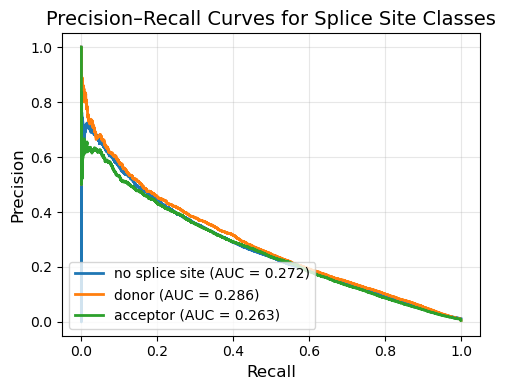

  PR-AUC for no splice site: 0.2722
  PR-AUC for donor: 0.2857
  PR-AUC for acceptor: 0.2634
Calculating top-k accuracy...
  Top-k accuracy for no splice site: 0.3346
  Top-k accuracy for donor: 0.3485
  Top-k accuracy for acceptor: 0.3343


In [16]:
%matplotlib inline
# Evaluate splice site classification
splice_eval = evaluate_splice_site_classification(
    true_labels, pred_probs, output_dir=None, log_fn=print
)

### Usage

In [17]:
# Combine true and predicted usage into one dataframe
all_sse = pd.merge(
    true_sse, pred_sse, how='outer', on=['sample_idx', 'position', 'condition_idx']
)
# Rename 'value' to predicted_usage' and 'sse' to 'true_usage' for clarity
all_sse = all_sse.rename(columns={'value': 'pred_sse', 'sse': 'true_sse'})

# Add condition names
all_sse['condition_name'] = all_sse['condition_idx'].astype(str).map(meta['usage_condition_mapping']).apply(lambda x: x['condition_key'] if isinstance(x, dict) else None)

# Extract tissue and timepoint from condition_name column (format: Tissue_timepoint)
all_sse['tissue'] = all_sse['condition_name'].str.split('_').str[0]
all_sse['timepoint'] = all_sse['condition_name'].str.split('_').str[1].astype(int)
all_sse

,sample_idx,position,condition_idx,alpha,beta,true_sse,pred_sse,condition_name,tissue,timepoint
0,0,0,0,1.0,0.0,1.0,0.498935,Brain_1,Brain,1
1,0,0,1,1.0,0.0,1.0,0.472838,Brain_5,Brain,5
2,0,0,2,NaN,NaN,NaN,0.441225,Brain_10,Brain,10
3,0,0,3,1.0,0.0,1.0,0.444084,Cerebellum_5,Cerebellum,5
4,0,0,4,NaN,NaN,NaN,0.000000,Cerebellum_10,Cerebellum,10
...,...,...,...,...,...,...,...,...,...,...
10756502,3618,4997,3,NaN,NaN,NaN,0.000000,Cerebellum_5,Cerebellum,5
10756503,3618,4997,4,NaN,NaN,NaN,0.000000,Cerebellum_10,Cerebellum,10
10756504,3618,4997,5,NaN,NaN,NaN,0.000000,Heart_1,Heart,1
10756505,3618,4997,6,NaN,NaN,NaN,0.000000,Heart_5,Heart,5


In [105]:
# Add species information from metadata
true_metadata['sample_idx'] = true_metadata.index
all_species = true_metadata[['sample_idx', 'species_id']]
all_sse['species_id'] = all_sse['sample_idx'].map(all_species.set_index('sample_idx')['species_id'])
all_sse['species_name'] = all_sse['species_id'].map(species_id_to_name)
all_sse

,sample_idx,position,condition_idx,alpha,beta,true_sse,pred_sse,condition_name,tissue,timepoint,species_id,species_name
0,0,0,0,1.0,0.0,1.0,0.498935,Brain_1,Brain,1,0,human
1,0,0,1,1.0,0.0,1.0,0.472838,Brain_5,Brain,5,0,human
2,0,0,2,NaN,NaN,NaN,0.441225,Brain_10,Brain,10,0,human
3,0,0,3,1.0,0.0,1.0,0.444084,Cerebellum_5,Cerebellum,5,0,human
4,0,0,4,NaN,NaN,NaN,0.000000,Cerebellum_10,Cerebellum,10,0,human
...,...,...,...,...,...,...,...,...,...,...,...,...
10756502,3618,4997,3,NaN,NaN,NaN,0.000000,Cerebellum_5,Cerebellum,5,1,mouse
10756503,3618,4997,4,NaN,NaN,NaN,0.000000,Cerebellum_10,Cerebellum,10,1,mouse
10756504,3618,4997,5,NaN,NaN,NaN,0.000000,Heart_1,Heart,1,1,mouse
10756505,3618,4997,6,NaN,NaN,NaN,0.000000,Heart_5,Heart,5,1,mouse


Some explaratory overlap analysis

In [98]:
all_true_sse = all_sse.dropna(subset=['true_sse'])
# max sse per sample and position
all_true_sse = all_true_sse.groupby(['sample_idx', 'position'])['true_sse'].max().reset_index()
all_true_sse.rename(columns={'true_sse': 'max_true_sse'}, inplace=True)
all_true_sse

,sample_idx,position,max_true_sse
0,0,0,1.000
1,1,2726,1.000
2,1,2837,1.000
3,1,4183,1.000
4,1,4317,1.000
...,...,...,...
14375,3618,3575,1.000
14376,3618,4114,1.000
14377,3618,4202,0.818
14378,3618,4705,0.125


In [99]:
all_predicted_sse = all_sse[['sample_idx', 'position', 'pred_sse']]
# max sse per sample and position
all_predicted_sse = all_predicted_sse.groupby(['sample_idx', 'position'])['pred_sse'].max().reset_index()
all_predicted_sse.rename(columns={'pred_sse': 'max_pred_sse'}, inplace=True)
all_predicted_sse

,sample_idx,position,max_pred_sse
0,0,0,0.518657
1,0,5,0.000000
2,0,30,0.193228
3,0,57,0.314651
4,0,58,0.000000
...,...,...,...
1344670,3618,4958,0.000000
1344671,3618,4960,0.000000
1344672,3618,4967,0.000000
1344673,3618,4979,0.573164


In [100]:
# Plot number of overlap and non-overlapping splice sites (sample_idx+position)
# in all_true_sse and all_predicted_sse sse and true_labels

all_true_sse['idx'] = all_true_sse['sample_idx'].astype(str) + "_" + all_true_sse['position'].astype(str)
all_predicted_sse['idx'] = all_predicted_sse['sample_idx'].astype(str) + "_" + all_predicted_sse['position'].astype(str)
true_labels['idx'] = true_labels['sample_idx'].astype(str) + "_" + true_labels['position'].astype(str)


overlap = set(all_true_sse['idx']).intersection(set(all_predicted_sse['idx']))
only_true = set(all_true_sse['idx']) - overlap
only_pred = set(all_predicted_sse['idx']) - overlap
print(f"\nSites for which we have measured SSE data and for which we predict SSE data:")
print(f"  Overlap: {len(overlap)} ({len(overlap) / len(set(all_true_sse['idx'])) * 100:.0f}% of sites with measured SSE data)")
print(f"  Only measured SSE: {len(only_true)}")
print(f"  Only predicted SSE: {len(only_pred)}")

overlap = set(all_true_sse['idx']).intersection(set(true_labels['idx']))
only_true = set(all_true_sse['idx']) - overlap
only_true_labels = set(true_labels['idx']) - overlap
print(f"\nSites for which we hae measured SSE data and which are annotated splice sites:")
print(f"  Overlap: {len(overlap)} ({len(overlap) / len(set(true_labels['idx'])) * 100:.0f}% of true splice sites)")
print(f"  Only measured SSE: {len(only_true)}")
print(f"  Only annotated: {len(only_true_labels)}")

overlap = set(all_predicted_sse['idx']).intersection(set(true_labels['idx']))
only_pred = set(all_predicted_sse['idx']) - overlap
only_true_labels = set(true_labels['idx']) - overlap
print(f"\nSites for which we predict SSE data and which are annotated splice sites:")
print(f"  Overlap: {len(overlap)} ({len(overlap) / len(set(true_labels['idx'])) * 100:.0f}% of true splice sites)")
print(f"  Only predicted SSE: {len(only_pred)}")
print(f"  Only annotated: {len(only_true_labels)}")


Sites for which we have measured SSE data and for which we predict SSE data:
  Overlap: 14380 (100% of sites with measured SSE data)
  Only measured SSE: 0
  Only predicted SSE: 1330295

Sites for which we hae measured SSE data and which are annotated splice sites:
  Overlap: 14380 (87% of true splice sites)
  Only measured SSE: 0
  Only annotated: 2140

Sites for which we predict SSE data and which are annotated splice sites:
  Overlap: 16006 (97% of true splice sites)
  Only predicted SSE: 1328669
  Only annotated: 514


In [107]:
correlation_df = calculate_condition_correlations(
    all_sse, group_by=['species_name', 'tissue', 'timepoint'], log_fn=print
)
correlation_df

Calculating correlations...
  Valid positions with both true and predicted SSE: 96736 (%0.90%)
  0 (0.00%) correlations are NaN
  Mean correlation: 0.2232
  Median correlation: 0.2268
  Std correlation: 0.0222


,species_name,tissue,timepoint,correlation,num_positions
0,human,Brain,1,0.211884,532
1,human,Brain,5,0.179801,532
2,human,Brain,10,0.203638,531
3,human,Cerebellum,5,0.247314,527
4,human,Heart,1,0.228736,472
5,human,Heart,5,0.209186,515
6,human,Heart,10,0.190100,485
7,mouse,Brain,1,0.219497,11227
8,mouse,Brain,5,0.245891,11781
9,mouse,Brain,10,0.221838,11980


Plotting SSE density...


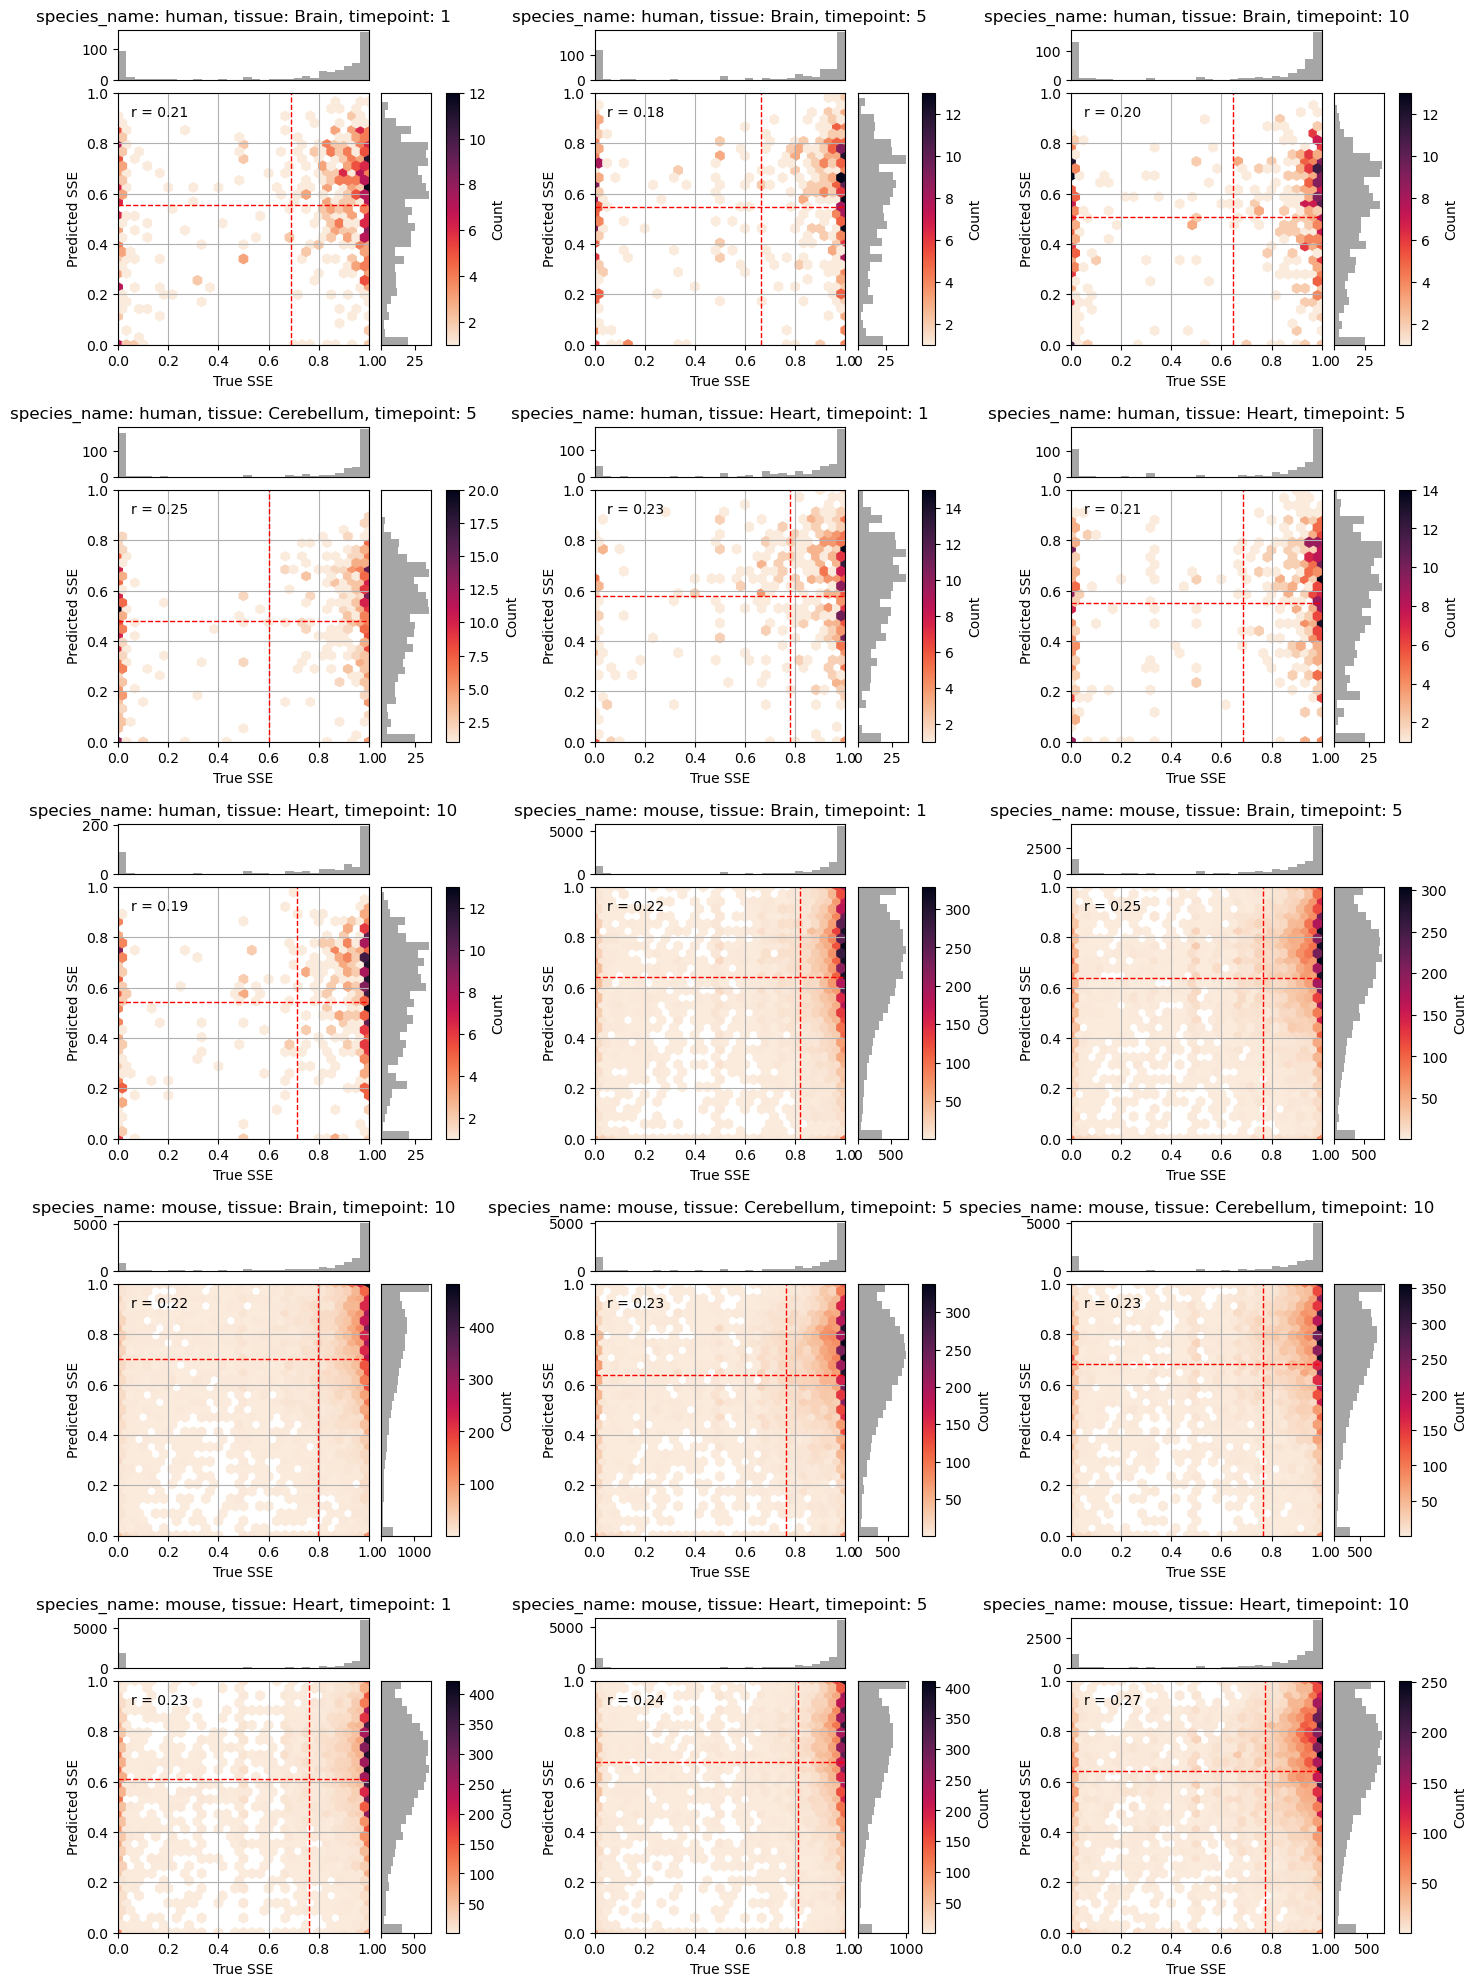

In [108]:
%matplotlib inline
plot_sse_density(all_sse, group_by=['species_name', 'tissue', 'timepoint'], output_dir=None, log_fn=print)